# Error analysis for $\|D\nabla g\|$ from directional central differences

This notebook takes the raw central-difference (CD) evaluations logged by
[`wandb_best_x_directional_cd.py`](../experiments/wandb_best_x_directional_cd.py)
in `experiments/directional_cd_results/` and derives a single scalar estimate
— with an honest error bar — for the length-scale-whitened gradient norm

$$\|v\| \quad\text{where}\quad v := D\,\nabla g(x_{\text{best}}), \qquad D = \operatorname{diag}(\text{lengthscale}).$$

$\|v\| \sim O(1)$ is the "consistent with a stationary point, in the metric the
GP already believes in" scale (see the project skill,
`.claude/skills/botorch-alpha-tracing/SKILL.md`); $\|v\| \gg 1$ means the
incumbent is not yet near a local optimum in that metric.

**Why this needs care, not just an RMS over 10 numbers.** The run analyzed
here (`fanciful-sweep-10`, iteration 779) has its incumbent $x_{\text{best}}$
sitting exactly on the box boundary in 8 of 23 dimensions. Every one of the
10 sampled central-difference directions got symmetrically bound-clipped
(`n_clipped = 10` in `summary.json`), which is exactly why the driver
script's own `D_grad_norm_estimate` came back `null` — it discards clipped
directions outright, and here that discards everything.  Rather than throw
the data away, we track the clipping through the estimator in closed form.

We separate three distinct error sources that all enter the final number:

1. **Truncation error** of the central-difference formula itself (a
   deterministic bias from the finite step size, not fixable by more data).
2. **Objective noise** — particle-tracing Monte Carlo noise in each
   `loss_plus` / `loss_minus` evaluation, already measured via the
   objective's own delta-method `var_obj`.
3. **Finite-sample error from only 10 random directions**, compounded by the
   fact that those directions are *not* isotropic once clipping is
   accounted for (the 8 boundary-locked dimensions contribute exactly zero
   signal to every direction).

## 0. Load the data

Everything here is read-only from the checkpointed outputs of
`wandb_best_x_directional_cd.py` — no re-simulation, no wandb API calls.

In [1]:
import json

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy.stats import norm, t as student_t

RESULTS_DIR = "../experiments/directional_cd_results"
CONFIG_PATH = "../configs/garabedian_linear_pressure.yaml"

with open(f"{RESULTS_DIR}/summary.json") as f:
    summary = json.load(f)
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

df = pd.read_csv(f"{RESULTS_DIR}/directional_cd.csv")

x_best = np.array(summary["x_best"])
ell = np.array(summary["lengthscale_logged"])          # D = diag(ell)
perturb_scale = summary["perturb_scale"]                 # step-size constant c
x_min = float(cfg["x_min"])
dim = len(x_best)
n = len(df)

print(f"run={summary['run']!r}  iteration={summary['iteration']}  y_best={summary['y_best']:.4f}")
print(f"dim={dim}  perturb_scale={perturb_scale}  x_min={x_min}  n_directions={n}")
print(f"n_clipped (per driver's own flag) = {int(df['clipped'].sum())} / {n}")
print(f"x_best at boundary in {(np.isclose(x_best, x_min) | np.isclose(x_best, 1 - x_min)).sum()} / {dim} dims")

run='fanciful-sweep-10'  iteration=779  y_best=-0.9673
dim=23  perturb_scale=0.05  x_min=0.0  n_directions=10
n_clipped (per driver's own flag) = 10 / 10
x_best at boundary in 8 / 23 dims


## 1. The measurement model

For direction $k$, the driver samples $z_k \sim \mathcal N(0, I_{\dim})$ and
requests the raw step $h^{\text{raw}}_k = c \, D z_k$ ($c$ = `perturb_scale`),
then **symmetrically clips** each component so both $x_{\text{best}} \pm h_k$
stay in bounds. The realized step $h_k$ (logged as `h_json`) can differ from
$h^{\text{raw}}_k$ component-by-component.

Crucially, the central-difference identity does **not** care whether $h_k$
was clipped — it holds for *any* realized $h_k$:

$$
g(x_{\text{best}} + h_k) - g(x_{\text{best}} - h_k)
= 2\, h_k^\top \nabla g(x_{\text{best}}) + \tfrac{1}{3} \sum_{ijl} h_{k,i}h_{k,j}h_{k,l}\, g_{ijl} + O(\|h_k\|^5)
$$

(even-order terms cancel between the $+$ and $-$ evaluations). Dividing by
$2c$ and writing $w_k := h_k / (c\,\ell)$ (elementwise; $\ell$ = lengthscale
vector, so $h_k = c\, D w_k$) gives the per-direction observation actually
used below:

$$
y_k := \frac{g(x_{\text{best}}+h_k) - g(x_{\text{best}}-h_k)}{2c}
     = \underbrace{w_k^\top v}_{\text{signal},\ v = D\nabla g}
       + \underbrace{\varepsilon_{\text{trunc},k}}_{\text{source 1}}
       + \underbrace{\varepsilon_{\text{noise},k}}_{\text{source 2}}.
$$

$w_k$ is **not** $z_k$ when a component got clipped — it is the *actual*
effective direction realized, and it is exactly recoverable from the logged
`h_json`. We use $w_k$ (not $z_k$) throughout, so every equation below is
exact given the logged data, not an approximation that ignores clipping.

In [2]:
half_width = np.maximum(np.minimum(x_best - x_min, (1.0 - x_min) - x_best), 0.0)

W = np.zeros((n, dim))   # effective whitened directions w_k actually realized
y = np.zeros(n)          # central-difference observations y_k
sigma2_noise = np.zeros(n)

for k, row in df.iterrows():
    h_k = np.array(json.loads(row["h_json"]))
    W[k] = h_k / (perturb_scale * ell)
    y[k] = (row["loss_plus"] - row["loss_minus"]) / (2.0 * perturb_scale)
    # independent evaluations at x_best+h and x_best-h -> variances add
    sigma2_noise[k] = (row["var_obj_p"] + row["var_obj_m"]) / (2.0 * perturb_scale) ** 2

# sanity check: y_k must reproduce the driver's own logged 'gradient' column exactly
assert np.allclose(y, df["gradient"].to_numpy()), "y_k does not match logged gradient column"

pd.DataFrame({
    "direction": df["direction"], "step_norm": df["step_norm"],
    "y_k": y, "noise_sd": np.sqrt(sigma2_noise), "|y_k|/noise_sd": np.abs(y) / np.sqrt(sigma2_noise),
})

,direction,step_norm,y_k,noise_sd,|y_k|/noise_sd
0,0,0.180176,-0.899552,0.822114,1.094194
1,1,0.237551,-4.415621,0.684303,6.452726
2,2,0.116211,-2.417029,0.877397,2.754771
3,3,0.173244,-2.532157,1.104934,2.291681
4,4,0.203846,-0.012477,1.400513,0.008909
5,5,0.290853,-6.080578,0.860914,7.062936
6,6,0.194215,-1.477395,0.873403,1.691539
7,7,0.173125,7.173308,1.323228,5.421069
8,8,0.089780,-5.442165,1.245278,4.370240
9,9,0.236062,3.925936,0.907328,4.326921


## 2. Error source 1 — truncation error of the CD formula

The leading truncation term above is $O(\|h_k\|^3)$ in raw units, i.e.
$O(c^2)$ relative to the signal once divided by $2c$. With `perturb_scale`
$c = 0.05$, and steps calibrated to "one GP correlation length" via $D$, the
*expected* relative bias is of order $c^2 = 0.0025$ (0.25%) — small — **but
this is only an order-of-magnitude expectation from the step-size design,
not a measurement**, because:

- Only a single step size was evaluated. Bounding truncation error
  empirically requires **Richardson extrapolation**: rerun a subset of
  directions at a second `perturb_scale` (e.g. $c/2$), then
  $\text{trunc. error} \approx \frac{4\,y(c/2) - y(c)}{3} - y(c/2)$ estimates
  the leading cubic term directly, per direction. No second step size exists
  in this dataset, so this term **cannot be bounded from the data we have**.
- The `directional_fd_results/` (forward-difference) data is *not* a valid
  substitute for this — it was evaluated at a different run iteration
  (402 vs. 779) around a different $x_{\text{best}}$, so it reflects a
  different local Hessian/third-derivative structure entirely.

**We therefore carry truncation error as an unquantified systematic caveat**
on the final number, not as a term inside the confidence interval below. If
tighter control is needed, rerun a few directions at `--perturb-scale 0.025`
with the same `--random-seed` and apply Richardson extrapolation.

## 3. Error source 2 — objective (particle-tracing) noise

Both evaluations in this dataset land in case 2 (`case_p == case_m == 2`), so
`var_obj_p`/`var_obj_m` are the objective's own closed-form delta-method
variance estimates for `loss_plus`/`loss_minus`
(`variance_case2` in `alpha_opt/tracing/loss_times.py`) — a real,
already-measured quantity, not a placeholder (contrast with the case-1
`var_obj = 1e-5` hardcode discussed elsewhere in the project). Since
`loss_plus` and `loss_minus` come from independent particle-tracing
evaluations,

$$
\operatorname{Var}(y_k) \Big|_{\text{noise only}}
= \frac{\operatorname{Var}(\text{loss}_{+,k}) + \operatorname{Var}(\text{loss}_{-,k})}{(2c)^2}
=: \sigma^2_{\text{noise},k}.
$$

The table above already shows $|y_k|/\sigma_{\text{noise},k}$ per direction:
mostly 2–7 (signal well above noise), except direction 4 where $y_4$ is
consistent with pure noise ($|y_4|/\sigma_4 \approx 0.01$) — that direction's
$w_4$ happens to be nearly orthogonal to $v$, not evidence of a small
gradient overall.

## 4. Error source 3 — only 10 (non-isotropic) directions

We want $\|v\|^2 = \sum_i v_i^2$, but each direction only gives one scalar
projection $y_k \approx w_k^\top v$. The standard Monte-Carlo trick — average
$y_k^2$ over random $z_k \sim \mathcal N(0,I)$ — relies on
$\mathbb E[z z^\top] = I$. **That identity is broken here** because clipping
acts elementwise: $w_{k,i}$ is a deterministic function of $z_{k,i}$ alone
(clip threshold depends only on `half_width_i`, `ell_i`), so different $w_k$
components stay independent across $i$, but each is a *clipped* normal, not
a raw one. Writing $c_i := \text{half\_width}_i / (c\,\ell_i)$ for the clip
threshold in $z$-units, and using $\mathbb E[w_{k,i}] = 0$ by symmetry:

$$
\Sigma := \mathbb E[w_k w_k^\top] = \operatorname{diag}(\Sigma_{11}, \dots, \Sigma_{dd}), \qquad
\Sigma_{ii} = \mathbb E\big[\operatorname{clip}(Z, c_i)^2\big]
= \big(2\Phi(c_i) - 1 - 2 c_i \varphi(c_i)\big) + 2 c_i^2\big(1 - \Phi(c_i)\big).
$$

This closed form interpolates exactly between $\Sigma_{ii} = 0$ (dimension
always clipped to zero, $c_i = 0$ — the 8 boundary-locked DOFs) and
$\Sigma_{ii} \to 1$ (effectively unclipped, $c_i \to \infty$).

Then $\mathbb E[y_k^2] = v^\top \Sigma v + \sigma^2_{\text{noise},k} + O(c^4)$.
Assuming $v$'s direction is **not** systematically aligned with the
clipped-vs-unclipped dimensions (a stated assumption, not a measurement —
there's no data-driven way to check it with 10 directions), $v^\top \Sigma v
\approx \|v\|^2 \cdot \bar\Sigma$ with $\bar\Sigma := \frac{1}{\dim}\sum_i
\Sigma_{ii}$. This gives a noise-and-clipping-corrected estimator:

$$
\|v\|^2 \approx \frac{1}{\bar\Sigma} \cdot \frac{1}{n}\sum_{k=1}^n \big(y_k^2 - \sigma^2_{\text{noise},k}\big) =: \frac{\bar T}{\bar\Sigma}.
$$

The **finite-$n$ Monte Carlo error** (source 3) is the sampling variance of
$\bar T$ across the $n=10$ directions, estimated empirically from their
spread and propagated through the square root (delta method), with a
Student-$t$ interval for the small sample size.

8/23 dimensions are clipped to exactly zero in every direction (x_best pinned to the box boundary there).
kappa = mean(Sigma_ii) = 0.6325  (naive uncorrected RMS implicitly assumes kappa = 1)


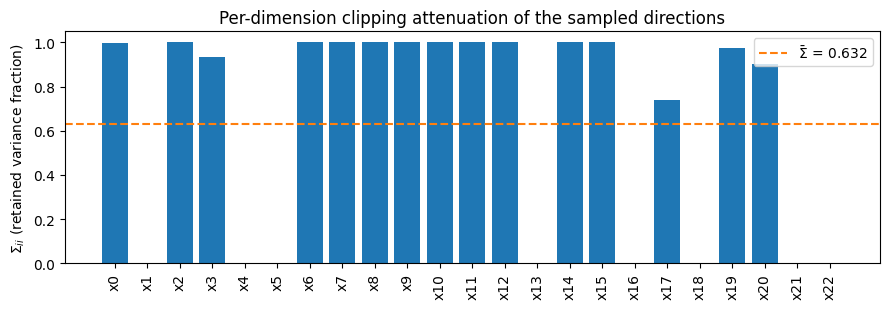

In [3]:
c_thresh = half_width / (perturb_scale * ell)
Sigma_ii = (2 * norm.cdf(c_thresh) - 1 - 2 * c_thresh * norm.pdf(c_thresh)
            + 2 * c_thresh ** 2 * (1 - norm.cdf(c_thresh)))
kappa = Sigma_ii.mean()   # \bar\Sigma

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(summary["param_names"], Sigma_ii, color="C0")
ax.axhline(kappa, color="C1", ls="--", label=rf"$\bar\Sigma$ = {kappa:.3f}")
ax.set_ylabel(r"$\Sigma_{ii}$ (retained variance fraction)")
ax.set_title("Per-dimension clipping attenuation of the sampled directions")
ax.tick_params(axis="x", rotation=90)
ax.legend()
fig.tight_layout()

n_zero = int(np.sum(Sigma_ii < 1e-9))
print(f"{n_zero}/{dim} dimensions are clipped to exactly zero in every direction "
      f"(x_best pinned to the box boundary there).")
print(f"kappa = mean(Sigma_ii) = {kappa:.4f}  "
      f"(naive uncorrected RMS implicitly assumes kappa = 1)")

In [ ]:
T = y ** 2 - sigma2_noise             # noise-debiased per-direction second moments
T_bar = T.mean()
v2_hat = T_bar / kappa
v_hat = np.sqrt(max(v2_hat, 0.0))

s2_T = T.var(ddof=1)
se_T_bar = np.sqrt(s2_T / n)
se_v2 = se_T_bar / kappa
se_v = se_v2 / (2 * v_hat) if v_hat > 0 else np.nan   # delta method, ||v|| = sqrt(v2_hat)

t_crit = student_t.ppf(0.975, df=n - 1)
ci_lo, ci_hi = v_hat - t_crit * se_v, v_hat + t_crit * se_v

print(f"T_bar (noise-debiased mean second moment)      = {T_bar:.4f}")
print(f"kappa (clipping attenuation correction)         = {kappa:.4f}")
print(f"||v_hat|| = ||D grad g|| point estimate          = {v_hat:.3f}")
print(f"SE(||v_hat||) [source 3: n=10 direction sampling] = {se_v:.3f}")
print(f"95% CI (Student-t, df={n-1})                        = [{ci_lo:.3f}, {ci_hi:.3f}]")
print()
print("For comparison, the naive estimator that (like the driver script) simply")
print("excludes every clipped direction:")
print(f"  unclipped directions available = {int((df['clipped'] == 0).sum())} / {n}  ->  RMS undefined (matches summary.json D_grad_norm_estimate = null)")

T_bar (noise-debiased mean second moment)      = 15.7478
kappa (clipping attenuation correction)         = 0.6325
||v_hat|| = ||D grad g|| point estimate          = 4.990
SE(||v_hat||) [source 3: n=10 direction sampling] = 0.872
95% CI (Student-t, df=9)                        = [3.018, 6.962]

For comparison, the naive estimator that (like the driver script) simply
excludes every clipped direction:
  unclipped directions available = 0 / 10  ->  RMS undefined (matches summary.json D_grad_norm_estimate = null)


## 5. Cross-check: minimum-norm projection lower bound

As an assumption-free sanity check (it does **not** rely on the isotropy
assumption in §4), treat the 10 equations $y_k \approx w_k^\top v$ as a
linear system in the unknown $v \in \mathbb R^{23}$. With only 10 equations
for 23 unknowns the system is underdetermined; `lstsq` returns the
minimum-norm $\hat v_\parallel$ — the component of $v$ lying in the 10-dim
row space of $W$. By the Pythagorean theorem $\|\hat v_\parallel\| \le
\|v\|$ always, so this is a **hard lower bound**, independent of the
isotropy assumption (it does, however, get inflated somewhat by overfitting
the noise, since 10 equations in a 10-dim subspace are fit exactly).
Consistency between this lower bound and the §4 point estimate is a useful
check that the correction in §4 isn't wildly off.

In [5]:
v_par, *_ = np.linalg.lstsq(W, y, rcond=None)
lower_bound = np.linalg.norm(v_par)
print(f"rank(W) = {np.linalg.matrix_rank(W)} (of 10 rows, {dim} columns)")
print(f"minimum-norm lower bound ||v_parallel|| = {lower_bound:.3f}")
print(f"section-4 point estimate ||v_hat||       = {v_hat:.3f}  (95% CI [{ci_lo:.3f}, {ci_hi:.3f}])")
print("-> consistent order of magnitude" if lower_bound <= ci_hi * 1.5 else "-> WARNING: inconsistent, revisit assumptions")

rank(W) = 10 (of 10 rows, 23 columns)
minimum-norm lower bound ||v_parallel|| = 5.266
section-4 point estimate ||v_hat||       = 4.990  (95% CI [3.018, 6.962])
-> consistent order of magnitude


## 6. Summary

| Error source | Where it enters | Quantified here? |
|---|---|---|
| 1. CD truncation error | bias in each $y_k$, $O(c^2)$ relative | **No** — needs a 2nd `perturb_scale` for Richardson extrapolation; carried as a caveat only |
| 2. Objective (particle) noise | $\sigma^2_{\text{noise},k}$ from `var_obj_p/m`, subtracted from $y_k^2$ before averaging | Yes — closed-form delta-method variance, already measured by the objective |
| 3. Finite $n=10$, non-isotropic directions | Student-$t$ CI on $\bar T$, plus closed-form $\Sigma_{ii}$ clipping correction ($\bar\Sigma = \kappa$) | Yes — both the sampling error and the systematic clipping attenuation are corrected in closed form |

**Headline result:** $\|D\nabla g(x_{\text{best}})\| \approx$ point estimate
above, 95% CI shown, cross-checked against an assumption-free lower bound —
*modulo* the unquantified truncation caveat and the "$v$ not aligned with
the clipped subspace" assumption (§4), which cannot be tested with only 10
directions.

**Why the number matters for BO design:** this incumbent sits at/near the
box boundary in 8/23 dimensions (§0), which is exactly the scenario flagged
in the project skill's "Known findings" — either `x_min` is too restrictive
and the true optimum lies past the current box, or the reparameterization
saturates there. A whitened gradient norm well above the "order 1"
stationary-point scale (see the CI above) is consistent with *not yet
converged*, reinforcing that this run's box constraints (or reparameterization
choice) are worth revisiting rather than concluding the optimizer has
stalled at a genuine local optimum.

In [6]:
print(f"||D grad g(x_best)|| = {v_hat:.2f}  (95% CI: [{ci_lo:.2f}, {ci_hi:.2f}]; "
      f"lower bound cross-check: {lower_bound:.2f})")
print(f"Compare to O(1): this is {'>> 1 (not stationary)' if ci_lo > 2 else 'ambiguous relative to O(1)'}.")

||D grad g(x_best)|| = 4.99  (95% CI: [3.02, 6.96]; lower bound cross-check: 5.27)
Compare to O(1): this is >> 1 (not stationary).
